In [1]:
from Qreservoir_fast import QReservoir
from tools import gen_input_states, gen_config_filepath, gen_system_filepath, gen_result_filepath, write_to_row, finish_row, unpack_config, folder_name

import numpy as np
import matplotlib.pyplot as plt
import os

#Pyörittelyt --------------------------------------------------------

In [2]:
gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding, n_models, n_train_inputs, n_test_inputs = unpack_config("Qreservoir_configurations/config6.json")

In [3]:
QReservoir_models = [QReservoir(gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding) for _ in range(n_models)]
train_inputs = np.array([gen_input_states("sq_th", n_train_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])

for Qreservoir in QReservoir_models:
    Qreservoir.init_reservoir("vacuum")
    Qreservoir.rk4_timesteps(4)

In [3]:
QReservoir_models = []

for i in range(n_models):
    systempath = gen_system_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity), i)
    Qres = QReservoir.init_from_file(systempath)
    QReservoir_models.append(Qres)

In [4]:
test_inputs_sq_th = np.array([gen_input_states("sq_th", n_test_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])
test_inputs_sq_pho_add = np.array([gen_input_states("pho_add", n_test_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])
test_inputs_sq_pho_sub = np.array([gen_input_states("pho_sub", n_test_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])
test_inputs_simple = np.array([gen_input_states("simple", n_test_inputs, fock_truncation, sim_rounding) for _ in range(n_models)])

In [5]:
for i in range(n_models):
    QReservoir_models[i].train_reservoir(train_inputs[i])
    systempath = gen_system_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity), i)
    QReservoir_models[i].system_save(systempath)

tr_res: (1+0j)
tr_new: (0.9999999999859999+0j)
0
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000113554+0j)
tr_res: (1+0j)
tr_new: (1.000000050224+0j)
tr_res: (1+0j)
tr_new: (1.0000000073909998+0j)
tr_res: (0.9999999403953552+0j)
tr_new: (0.999999971996+0j)
tr_res: (1+0j)
tr_new: (1.000000005525+0j)
tr_res: (0.9999999403953552+0j)
tr_new: (0.9999999701420001+0j)
tr_res: (0.9999999403953552+0j)
tr_new: (0.999999919843+0j)
tr_res: (0.9999998807907104+0j)
tr_new: (0.9999998639629999+0j)
tr_res: (0.9999998807907104+0j)
tr_new: (0.999999893769+0j)
tr_res: (0.9999998807907104+0j)
tr_new: (0.999999904945+0j)
tr_res: (0.9999997615814209+0j)
tr_new: (0.9999997577830001+0j)
tr_res: (0.9999997615814209+0j)
tr_new: (0.9999997633800001+0j)
tr_res: (0.9999997019767761+0j)
tr_new: (0.99999970191+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.9999997019200002+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.9999996683779999+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.999999655349+0j)
tr_res: (0.9999

In [7]:
QReservoir_models[7] = QReservoir(gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding)
train_inputs[7] = gen_input_states("sq_th", n_train_inputs, fock_truncation, sim_rounding)

QReservoir_models[7].init_reservoir("vacuum")
QReservoir_models[7].rk4_timesteps(4)

In [9]:
QReservoir_models[7].train_reservoir(train_inputs[7])
systempath = gen_system_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity), 7)
QReservoir_models[7].system_save(systempath)

tr_res: (1+0j)
tr_new: (0.999999999988+0j)
0
tr_res: (0.9999998807907104+0j)
tr_new: (0.9999998597469999+0j)
tr_res: (0.9999998807907104+0j)
tr_new: (0.9999998102050001+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.9999996454169999+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.9999995779640001+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.9999995217850001+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.9999995794130001+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.9999995654739999+0j)
tr_res: (0.999999463558197+0j)
tr_new: (0.9999994804679999+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.999999564541+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.9999995387629999+0j)
tr_res: (0.9999995231628418+0j)
tr_new: (0.999999578955+0j)
tr_res: (0.9999997019767761+0j)
tr_new: (0.999999669995+0j)
tr_res: (0.9999996423721313+0j)
tr_new: (0.9999996601269999+0j)
tr_res: (0.9999995827674866+0j)
tr_new: (0.999999611612+0j)
tr_res: (0.999999463558197+0j)
tr_new: (0.9999994765600001+0j)
tr_res: (0.99

In [6]:
resultpath = gen_result_filepath(folder_name(gamma, reservoir_size, fock_truncation, reservoir_connectivity))

In [16]:
res = QReservoir_models[0].analyze_performance(QReservoir_models[0].test_Y_true, QReservoir_models[0].test_Y_pred)
write_to_row(str(res), resultpath)

In [7]:
for i in range(n_models):
    QReservoir_models[i].reset_after_test()
    result = QReservoir_models[i].test_reservoir(test_inputs_sq_th[i])
    write_to_row(str(result), resultpath)

finish_row(resultpath)

tr_res: (0.9999982714653015+0j)
tr_new: (0.9999982211099999+0j)
0
tr_res: (0.9999982714653015+0j)
tr_new: (0.9999982676760001+0j)
tr_res: (0.9999982714653015+0j)
tr_new: (0.9999983123770001+0j)
tr_res: (0.9999983310699463+0j)
tr_new: (0.9999982956150001+0j)
tr_res: (0.9999983906745911+0j)
tr_new: (0.999998396192+0j)
tr_res: (0.9999985098838806+0j)
tr_new: (0.9999985023660002+0j)
tr_res: (0.9999985694885254+0j)
tr_new: (0.9999985917769999+0j)
tr_res: (0.9999985098838806+0j)
tr_new: (0.9999985042309999+0j)
tr_res: (0.9999985694885254+0j)
tr_new: (0.999998548933+0j)
tr_res: (0.9999987483024597+0j)
tr_new: (0.9999987352019998+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.9999988488210001+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.9999987650089998+0j)
tr_res: (0.9999987483024597+0j)
tr_new: (0.999998761269+0j)
tr_res: (0.999998927116394+0j)
tr_new: (0.9999989270599999+0j)
tr_res: (0.999998927116394+0j)
tr_new: (0.9999989140109999+0j)
tr_res: (0.9999988675117493+0j)
tr_new: (0.999998858

In [18]:
for i in range(n_models):
    QReservoir_models[i].reset_after_test()
    result = QReservoir_models[i].test_reservoir(test_inputs_sq_pho_add[i])
    write_to_row(str(result), resultpath)

finish_row(resultpath)

tr_res: (0.9999988079071045+0j)
tr_new: (0.9999987994309999+0j)
0
tr_res: (0.9999988079071045+0j)
tr_new: (0.9999987997840001+0j)
tr_res: (0.999998927116394+0j)
tr_new: (0.999998913113+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.9999988709149998+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.999998819341+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.999998754149+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.9999987649759999+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.9999987779520001+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.9999987799319999+0j)
tr_res: (0.9999986886978149+0j)
tr_new: (0.999998663196+0j)
tr_res: (0.9999986886978149+0j)
tr_new: (0.9999987252179999+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.99999883791+0j)
tr_res: (0.9999988079071045+0j)
tr_new: (0.9999988382889999+0j)
tr_res: (0.9999988675117493+0j)
tr_new: (0.9999988276009999+0j)
tr_res: (0.9999988675117493+0j)
tr_new: (0.999998847277+0j)
tr_res: (0.9999988675117493+0j)
tr_new: (0.9999988849120001+0j)


KeyboardInterrupt: 

In [ ]:
for i in range(n_models):
    QReservoir_models[i].reset_after_test()
    result = QReservoir_models[i].test_reservoir(test_inputs_sq_pho_sub[i])
    write_to_row(str(result), resultpath)

finish_row(resultpath)

In [ ]:
for i in range(n_models):
    QReservoir_models[i].reset_after_test()
    result = QReservoir_models[i].test_reservoir(test_inputs_simple[i])
    write_to_row(str(result), resultpath)

finish_row(resultpath)

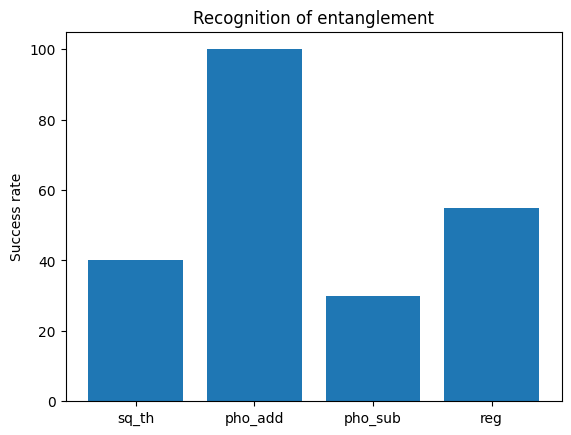

In [ ]:
#Plot the probability of correct classification
fig, ax = plt.subplots()

input_types = ['sq_th', 'pho_add', 'pho_sub', 'reg']
counts = [40, 100, 30, 55]
ax.bar(input_types, counts)

ax.set_ylabel('Success rate')
ax.set_title('Recognition of entanglement')

plt.show()

In [3]:
train_in = gen_input_states("sq_th", 20, fock_truncation, sim_rounding)

test_pho_add = gen_input_states("pho_add", 1000, fock_truncation)
test_pho_sub = gen_input_states("pho_sub", 1000, fock_truncation)
test_simple = gen_input_states("simple", 1000, fock_truncation)
test_sq_th = gen_input_states("sq_th",1000, fock_truncation)

In [4]:
Qres1 = QReservoir(gamma, reservoir_size, fock_truncation, reservoir_connectivity, sim_rounding)
Qres1.init_reservoir("vacuum")
Qres1.rk4_timesteps(4)

In [9]:
Qres1.train_reservoir(train_in)

tr_res: (1+0j)
tr_new: (0.99999999999+0j)
0
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000006256+0j)
tr_res: (1+0j)
tr_new: (1.000000016474+0j)
tr_res: (1+0j)
tr_new: (1.000000031781+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.0000000827039999+0j)
tr_res: (1+0j)
tr_new: (1.000000031157+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000092539+0j)
tr_res: (1.000000238418579+0j)
tr_new: (1.000000201162+0j)
tr_res: (1.0000001192092896+0j)
tr_new: (1.000000122081+0j)
tr_res: (0.9999998807907104+0j)
tr_new: (0.999999883691+0j)
tr_res: (0.9999998211860657+0j)
tr_new: (0.999999896657+0j)
tr_res: (0.9999998211860657+0j)
tr_new: (0.9999998775910001+0j)
tr_res: (0.9999997019767761+0j)
tr_new: (0.9999996913350001+0j)
tr_res: (0.9999997019767761+0j)
tr_new: (0.999999709024+0j)
tr_res: (0.9999997019767761+0j)
tr_new: (0.999999662833+0j)
tr_res: (0.9999997615814209+0j)
tr_new: (0.9999996969010001+0j)
tr_res: (0.9999997615814209+0j)
tr_new: (0.9999997459780001+0j)
tr_res: (0.9999997019767761+

In [10]:
result = Qres1.test_reservoir(test_simple)


tr_res: (0.9999996423721313+0j)
tr_new: (0.9999997615814209-3.2760003598752974e-09j)
0
tr_res: (0.9999997615814209-3.2629998703015417e-09j)
tr_new: (0.9999997615814209-9.457999716744325e-09j)
tr_res: (0.9999997019767761-9.45999989454549e-09j)
tr_new: (0.9999998211860657-1.0814999562569483e-08j)
tr_res: (0.9999997019767761-1.0842000186528367e-08j)
tr_new: (0.9999998211860657-1.0906001435273538e-08j)
tr_res: (0.9999997615814209-1.0909999126340608e-08j)
tr_new: (0.9999997615814209-1.9815999507954984e-08j)
tr_res: (0.9999998211860657-1.980099995080309e-08j)
tr_new: (0.9999997615814209-2.3876999932781473e-08j)
tr_res: (0.9999998211860657-2.3873999666079726e-08j)
tr_new: (0.9999998211860657-2.3475999810784742e-08j)
tr_res: (0.9999997615814209-2.3509999280690863e-08j)
tr_new: (0.9999996423721313-2.1019001650302016e-08j)
tr_res: (0.9999996423721313-2.1036001385255076e-08j)
tr_new: (0.9999996423721313-2.3687999117782965e-08j)
tr_res: (0.9999995827674866-2.368099849547889e-08j)
tr_new: (0.999999

In [11]:
from tools import init_destroy, init_identity, tensor, dagger, init_two_mode_sq, init_vac, assess_dm_entanglement, init_simple, assess_dm_entanglement, dagger

In [5]:
def get_entanglement_values(inputs):
    return np.array([[1,0] if assess_dm_entanglement(input, "first", fock_truncation, fock_truncation, 2) > 0 else [0,1] for input in inputs])

In [21]:
for input in test_simple:
    print(np.trace(input))

(0.99999994-6.220887e-09j)
(1+5.9966954e-10j)
(1+6.308923e-09j)
(1+6.6948402e-09j)
(1-2.8498688e-09j)
(1-4.857931e-09j)
(1.0000001+8.408922e-09j)
(1-1.2338637e-09j)
(1+4.8587196e-09j)
(1+1.1769885e-08j)
(1+2.2622935e-09j)
(1+1.9920066e-10j)
(1-4.0899195e-10j)
(0.9999999-2.8612135e-09j)
(1+3.6029846e-11j)
(0.99999994-6.5567143e-09j)
(1-2.494109e-09j)
(1-4.7614233e-09j)
(1+5.6744653e-10j)
(0.99999994-1.1108503e-11j)
(1-5.229108e-09j)
(1+2.139779e-09j)
(1+3.853713e-09j)
(1+3.0276324e-09j)
(1+9.585506e-09j)
(0.99999994+1.3389126e-08j)
(1+4.3865818e-09j)
(0.99999994+2.6488833e-10j)
(1+2.8715785e-09j)
(1-5.6613203e-10j)
(1-1.8660558e-09j)
(1-6.063212e-10j)
(1+1.469027e-08j)
(1-1.0615473e-09j)
(1+1.0163166e-08j)
(1-8.0664275e-10j)
(1+1.11555654e-10j)
(0.99999994+1.6864403e-09j)
(1+2.6280045e-10j)
(1-7.3380093e-09j)
(0.99999994+1.7683899e-10j)
(1+6.6415957e-09j)
(1-3.0133105e-09j)
(1.0000001+5.548058e-09j)
(1-6.9682002e-09j)
(1+2.735807e-10j)
(1+9.1466834e-10j)
(1-2.956284e-09j)
(1-7.4115825e-

In [17]:
test_pho_add[3]-dagger(test_pho_add[3])

array([[ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j],
       [ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+0

In [12]:
np.round(dagger(test_pho_add[0]),5)

array([[ 0.     -0.j     ,  0.     -0.j     ,  0.     -0.j     ,
         0.     -0.j     ,  0.     -0.j     ,  0.     -0.j     ,
         0.     -0.j     ,  0.     -0.j     ,  0.     -0.j     ,
         0.     -0.j     ,  0.     -0.j     ,  0.     -0.j     ,
         0.     -0.j     ,  0.     -0.j     ,  0.     -0.j     ,
         0.     -0.j     ,  0.     -0.j     ,  0.     -0.j     ,
         0.     -0.j     ,  0.     -0.j     ,  0.     -0.j     ,
         0.     -0.j     ,  0.     -0.j     ,  0.     -0.j     ,
         0.     -0.j     ],
       [ 0.     -0.j     ,  0.     -0.j     ,  0.     -0.j     ,
         0.     -0.j     ,  0.     -0.j     ,  0.     -0.j     ,
         0.     -0.j     ,  0.     -0.j     ,  0.     -0.j     ,
         0.     -0.j     ,  0.     -0.j     ,  0.     -0.j     ,
         0.     -0.j     ,  0.     -0.j     ,  0.     -0.j     ,
         0.     -0.j     ,  0.     -0.j     ,  0.     -0.j     ,
         0.     -0.j     ,  0.     -0.j     ,  0.     -0.j    

In [6]:
for input in test_pho_add:
    print(assess_dm_entanglement(input, "first", fock_truncation, fock_truncation, 5))


1.17388
1.06999
0.95538
0.85742
1.12166
1.15163
0.68885
0.63944
1.08253
1.19552
1.01233
0.86096
0.80648
0.90981
0.84808
0.55154
0.7142
0.97712
1.20181
1.11451
1.06238
0.66861
0.64811
1.01628
1.0411
1.11892
0.70666
1.18978
1.19809
0.84657
0.55889
0.62401
0.78799
0.89484
1.18714
0.6288
0.7535
1.20435
0.54735
0.58294
1.20412
0.93666
1.12416
1.12731
0.83893
0.95426
0.66732
0.94414
0.91734
0.95718
1.05058
0.75708
1.10499
0.85549
0.6022
0.71635
0.90535
0.62334
1.15148
0.67264
0.86659
0.57834
0.97686
0.89517
1.1532
1.10309
0.9657
0.79863
1.16152
0.89506
0.60169
0.97389
0.55111
0.66221
0.94815
0.79334
0.62142
1.03255
1.12128
1.05871
0.56564
0.77223
1.15956
1.03618
0.67464
0.86237
1.19847
1.05721
1.05487
0.91012
0.65017
1.1811
0.77286
0.93633
0.61856
0.86442
0.99134
0.79937
1.05669
0.96324
0.91345
0.96758
1.07315
0.98367
1.00677
0.88326
1.22355
0.81955
0.76442
0.82219
1.03513
1.12893
0.65182
0.8764
1.03307
0.7943
1.12266
0.7767
1.1327
0.56972
0.93074
1.17841
0.64759
0.58061
0.88849
0.79597
1.00

In [10]:
truncate = 5
amount_of_states = 10000

a1 = tensor([init_destroy(truncate), init_identity(truncate)])
a2 = tensor([init_identity(truncate), init_destroy(truncate)])
        
abs_alpha_pho_add_ = np.random.uniform(0.1, 0.25, (amount_of_states,))
theta_pho_add_ = np.random.uniform(0,2*np.pi,(amount_of_states,))
alpha_pho_add_ = np.array([x*np.exp(1j*y) for x, y in zip(abs_alpha_pho_add_,theta_pho_add_)])  

abs_alpha_pho_sub_ = np.random.uniform(0.8, 0.95, (amount_of_states,))
theta_pho_sub_ = np.random.uniform(0,2*np.pi,(amount_of_states,))
alpha_pho_sub_ = np.array([x*np.exp(1j*y) for x, y in zip(abs_alpha_pho_sub_,theta_pho_sub_)])

theta_simple_ = np.array([np.arcsin(np.sqrt(x)) for x in np.random.uniform(0,1,(amount_of_states,))])
phi_simple_ = np.random.uniform(0,2*np.pi,(amount_of_states,))
c0_simple_ = np.array([np.sin(x) for x in theta_simple_])
c1_simple_ = np.array([np.cos(x)*np.exp(1j*y) for x,y in zip(theta_simple_, phi_simple_)])

In [11]:
counter = 0
for c0, c1 in zip(c0_simple_,c1_simple_):
    if np.abs(c0**2-np.abs(c1**2)) > 0.5:
        counter += 1
print(counter)

4958
